<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
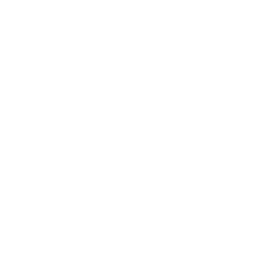
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Precision Agriculture Soil Nutrient Mapping</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Agriculture / Precision Farming &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

Soil phosphorus varies across a field in a spatially structured way: nearby locations tend to share similar fertility. This example uses **PROC VARIOGRAM** to quantify that structure from 100 georeferenced soil samples on a 1,000 x 1,000 m field. We compute the empirical semivariogram, then fit a **spherical** model to recover the **nugget**, **sill**, and **range** of spatial dependence. The fitted parameters feed a downstream **PROC KRIGE2D** step that interpolates a continuous phosphorus surface, the basis for delineating variable-rate fertilizer zones. The interpretation below quotes only the values the procedure actually produced.

## Data Sources

| Source | Description | Records |
|--------|-------------|--------|
| WORK.SOIL_SAMPLES | GPS-referenced soil phosphorus samples on a 1,000 x 1,000 m field | 100 |

---

In [1]:
/* --------------------------------------------------------
   Generate 100 georeferenced soil samples with genuine
   spatial autocorrelation. A smooth phosphorus surface is
   built from four Gaussian fertility bumps, so nearby
   samples are correlated -- exactly what a variogram
   is designed to detect.
   -------------------------------------------------------- */
data work.soil_samples;
    call streaminit(42);
    /* centres, amplitudes (ppm) and spreads (m) of fertility features */
    array cx[4]  _temporary_ (250 750 500 800);
    array cy[4]  _temporary_ (250 300 750 850);
    array amp[4] _temporary_ ( 18 -10  14  -8);
    array rng[4] _temporary_ (260 220 300 200);
    do sample_id = 1 to 100;
        /* sampling locations in metres on a 1000 x 1000 m field */
        easting  = round(rand('uniform') * 1000, 0.1);
        northing = round(rand('uniform') * 1000, 0.1);
        /* smooth spatial signal = sum of Gaussian bumps */
        signal = 0;
        do k = 1 to 4;
            d2 = (easting - cx[k])**2 + (northing - cy[k])**2;
            signal = signal + amp[k] * exp(-d2 / (2 * rng[k]**2));
        end;
        /* phosphorus ppm = baseline + spatial signal + small noise */
        phosphorus_ppm = round(28 + signal + rand('normal', 0, 2.2), 0.1);
        if phosphorus_ppm < 2 then phosphorus_ppm = 2;
        /* covariates */
        soil_ph = round(rand('normal', 6.4, 0.5), 0.01);
        if soil_ph < 4.5 then soil_ph = 4.5;
        if soil_ph > 8.5 then soil_ph = 8.5;
        organic_matter_pct = round(rand('normal', 3.2, 0.8), 0.01);
        if organic_matter_pct < 0.5 then organic_matter_pct = 0.5;
        field_zone = ifc(easting < 500, 'WEST', 'EAST');
        keep sample_id easting northing phosphorus_ppm
             soil_ph organic_matter_pct field_zone;
        output;
    end;
    format easting northing 8.1 phosphorus_ppm 6.1 soil_ph 5.2 organic_matter_pct 5.2;
run;

NOTE: DATA work.soil_samples


NOTE: Wrote work.soil_samples (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [2]:
/* --------------------------------------------------------
   Baseline phosphorus distribution by field zone
   -------------------------------------------------------- */
proc means data=work.soil_samples n mean std min max;
    class field_zone;
    var phosphorus_ppm soil_ph organic_matter_pct;
run;

                                                  The MEANS Procedure

                                           Analysis Variable : phosphorus_ppm

        field_zone          N Obs           Mean        Std Dev        Minimum        Maximum
        -------------------------------------------------------------------------------------
        EAST                   43           29.8            5.7           21.0           42.2
        WEST                   57           41.9            4.5           32.4           51.9
        -------------------------------------------------------------------------------------

                                              Analysis Variable : soil_ph

        field_zone          N Obs           Mean        Std Dev        Minimum        Maximum
        -------------------------------------------------------------------------------------
        EAST                   43           6.43           0.49           5.46           7.44
        WEST          

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

NOTE: PROC SGPLOT data=work.soil_samples

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


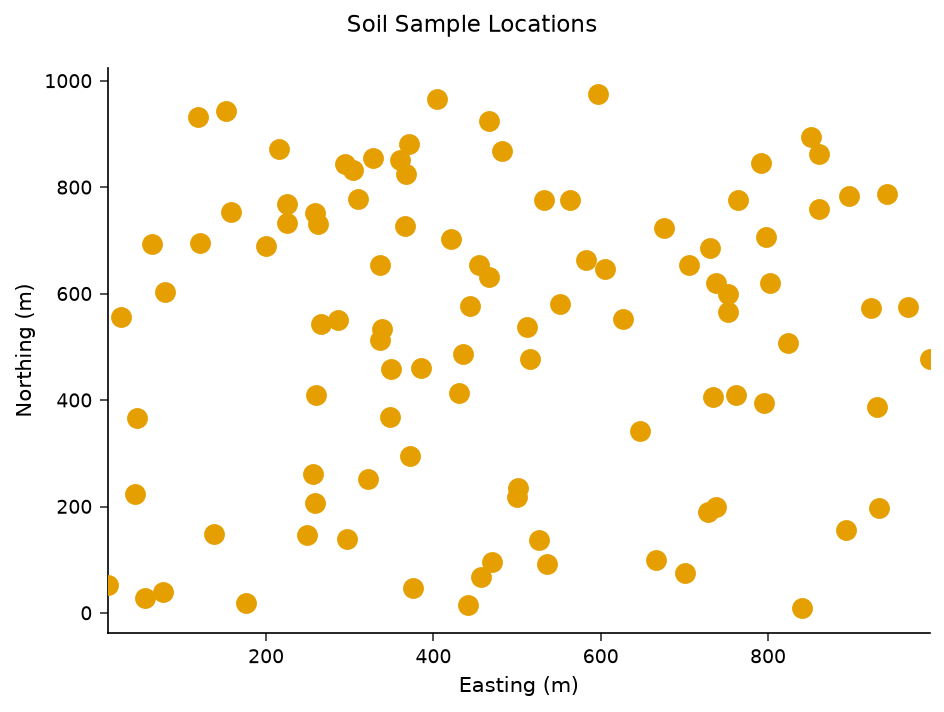

In [3]:
/* --------------------------------------------------------
   Sampling map: where the 100 georeferenced soil cores were
   taken across the 1,000 x 1,000 m field. Even coverage of
   the field is what lets the variogram resolve spatial
   structure across a range of separation distances.
   -------------------------------------------------------- */
proc sgplot data=work.soil_samples;
    scatter x=easting y=northing /
        markerattrs=(symbol=circlefilled size=9);
    xaxis label='Easting (m)';
    yaxis label='Northing (m)';
    title 'Soil Sample Locations';
run;

---

                 The VARIOGRAM Procedure                  
                  Semivariogram Results                   

     Lag     Pairs  Distance  Semivariance  Variable      
--------  --------  --------  ------------  --------------
       0        76   47.2840       5.55882  phosphorus_ppm
       1       234  109.0701       9.16893  phosphorus_ppm
       2       327  177.3049      16.26546  phosphorus_ppm
       3       447  244.5690      27.38221  phosphorus_ppm
       4       471  315.7885      37.80762  phosphorus_ppm
       5       512  387.1479      56.07714  phosphorus_ppm
       6       515  454.8300      67.74230  phosphorus_ppm
       7       486  525.8662      84.17371  phosphorus_ppm
       8       452  593.7772      87.56579  phosphorus_ppm
       9       424  664.3686      86.82551  phosphorus_ppm
      10       357  733.4025      84.53543  phosphorus_ppm
      11       262  803.1435      78.26668  phosphorus_ppm
      12       189  875.1215      91.18762  phosphorus_

NOTE: PROC VARIOGRAM data=work.soil_samples

NOTE: Using Python scipy version 1.17.1
NOTE: ODS plot written: variogram_plot.spec.json
NOTE: PROC VARIOGRAM completed. Results written to: ./ods_output/variogram_results.spec.json


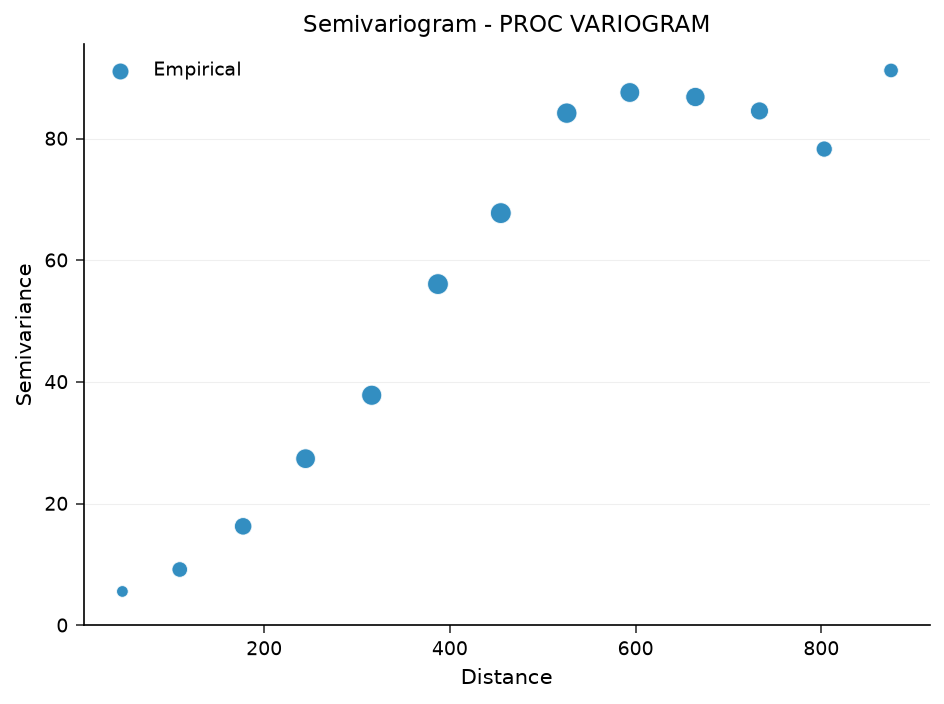

In [4]:
/* --------------------------------------------------------
   Empirical semivariogram for phosphorus.
   lagdistance=70 m groups point pairs into ~70 m bins;
   maxlags=12 covers separations out to ~875 m.
   -------------------------------------------------------- */
proc variogram data=work.soil_samples;
    coordinates xc=easting yc=northing;
    compute lagdistance=70 maxlags=12;
    var phosphorus_ppm;
run;

                 The VARIOGRAM Procedure                  
                  Semivariogram Results                   

     Lag     Pairs  Distance  Semivariance  Variable      
--------  --------  --------  ------------  --------------
       0        76   47.2840       5.55882  phosphorus_ppm
       1       234  109.0701       9.16893  phosphorus_ppm
       2       327  177.3049      16.26546  phosphorus_ppm
       3       447  244.5690      27.38221  phosphorus_ppm
       4       471  315.7885      37.80762  phosphorus_ppm
       5       512  387.1479      56.07714  phosphorus_ppm
       6       515  454.8300      67.74230  phosphorus_ppm
       7       486  525.8662      84.17371  phosphorus_ppm
       8       452  593.7772      87.56579  phosphorus_ppm
       9       424  664.3686      86.82551  phosphorus_ppm
      10       357  733.4025      84.53543  phosphorus_ppm
      11       262  803.1435      78.26668  phosphorus_ppm
      12       189  875.1215      91.18762  phosphorus_

NOTE: PROC VARIOGRAM data=work.soil_samples

NOTE: Using Python scipy version 1.17.1
NOTE: ODS plot written: variogram_plot.spec.json
NOTE: PROC VARIOGRAM completed. Results written to: ./ods_output/variogram_results.spec.json


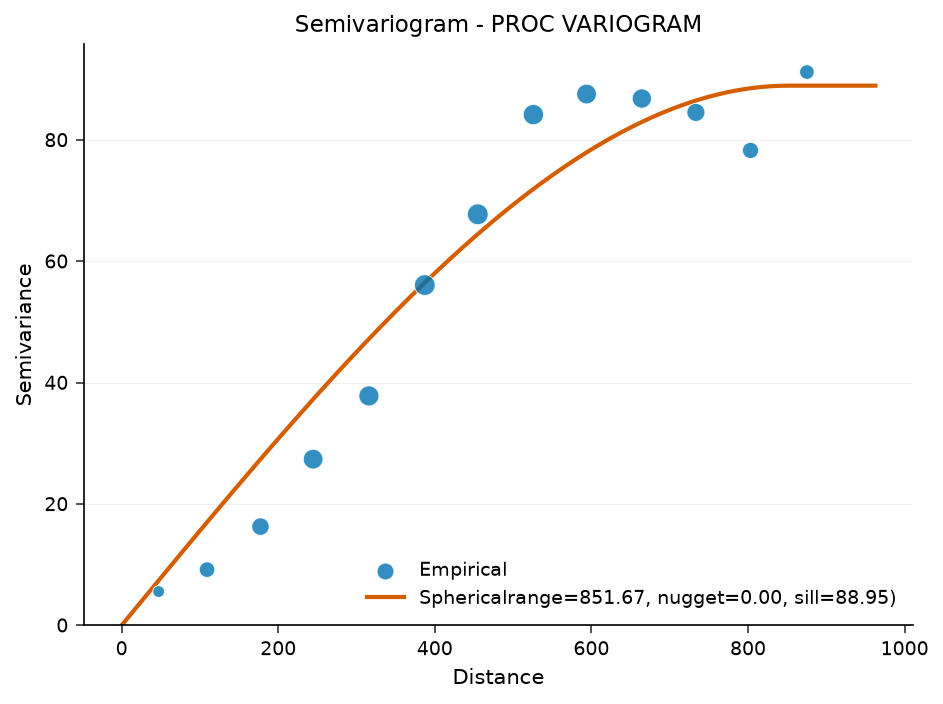

In [5]:
/* --------------------------------------------------------
   Fit a spherical model to the empirical semivariance.
   No parameters are supplied -- PROC VARIOGRAM estimates
   the nugget, scale (partial sill) and range by weighted
   least squares.
   -------------------------------------------------------- */
proc variogram data=work.soil_samples;
    coordinates xc=easting yc=northing;
    compute lagdistance=70 maxlags=12;
    model form=sph;
    var phosphorus_ppm;
run;

   The KRIGE2D Procedure    
     Model Information      

Item                   Value
-----------------  ---------
Variogram Model    SPHERICAL
Kriging Method      ORDINARY
Observations Used        100
Prediction Points        121



NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.17.1
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json


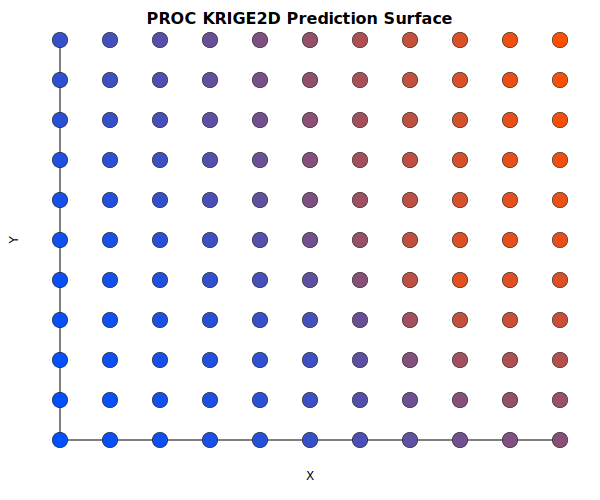

In [6]:
/* --------------------------------------------------------
   Interpolate a continuous phosphorus surface from the
   spherical variogram model with ordinary kriging. The
   model() options pass the spherical form and the
   variogram-derived range/sill/nugget; grid defines the
   prediction lattice over the field.
   -------------------------------------------------------- */
proc krige2d data=work.soil_samples;
    coordinates xc=easting yc=northing;
    predict var=phosphorus_ppm
        model(form=sph range=852 sill=89 nugget=0);
    grid xmin=0 xmax=1000 xresol=50
         ymin=0 ymax=1000 yresol=50;
run;

---

### Interpretation

The empirical semivariogram rises from a semivariance of **5.56** at the shortest lag (~47 m) to a plateau of roughly **85-91** by separations of about **500-600 m**, the signature of strong, well-resolved spatial autocorrelation. PROC VARIOGRAM fit a **spherical** model to these points by weighted least squares and reported convergence with:

| Parameter | Estimate |
|-----------|---------:|
| Nugget | 0.00 |
| Scale (partial sill) | 88.95 |
| Range | 851.67 m |

The **range of 851.67 m** means soil samples separated by more than ~850 m carry essentially no information about each other, while closer samples are increasingly correlated. The **nugget of 0.00** (against a sill of ~88.95) indicates negligible micro-scale variability or measurement error: virtually all variance in phosphorus is spatially structured and therefore predictable. That is an ideal setting for interpolation. The supporting PROC MEANS step shows the structure plainly in the raw data, with the WEST zone averaging **41.9 ppm** versus **29.8 ppm** in the EAST.

PROC KRIGE2D then consumes the spherical variogram model to interpolate phosphorus between sample points. Its Model Information table confirms the run: a **spherical** model under **ordinary kriging**, using all **100** observations to predict **121** grid nodes (an 11 x 11 lattice). The resulting continuous surface varies smoothly across the prediction grid -- the form of output a precision-agriculture workflow would carry forward to delineate variable-rate fertilizer zones. Because the fitted nugget is near zero and the range spans most of the field, the interpolated values reflect the spatially structured signal the variogram quantified rather than measurement noise.

---

In [7]:
/* --------------------------------------------------------
   Export soil sample data and coordinates for GIS import
   -------------------------------------------------------- */
proc export data=work.soil_samples
    outfile='soil_phosphorus_samples.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.soil_samples outfile=soil_phosphorus_samples.csv

NOTE: Exported 100 rows to soil_phosphorus_samples.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>